## Fusing FinBERT and ABSA: can we take direction from one and intensity from the other?

Notebook 2.3 left one question open and could not answer it. We carry two sentiment scorers over
the same sentences, they disagree on the SIGN of sentiment for 23.2% of non-comparative target
sentences, and the only evidence about which one is right was 25 sentences that had been picked
*because* they disagreed -- the most favourable possible sample for whichever model wins
disagreements. 2.3 recommended keeping both column families precisely because that evidence could
not settle anything.

This notebook settles it, by hand, on a sample that was not picked to flatter anybody.

**The hypothesis.** The two models are good at different halves of the same question:

- **FinBERT** scores a SENTENCE. It is finance-trained, so its sense of *how big a deal* something
  is should be calibrated on financial language -- "missed on adjusted profits" versus "slightly
  below consensus".
- **ABSA** scores sentiment TOWARD AN ASPECT. It is trained on product reviews, not finance, but it
  is the only one of the two that knows *who the sentiment is about*.

If **attribution** and **intensity** are separable, then the right construction takes direction from
ABSA and magnitude from FinBERT, and should beat either model alone.

**What we do.** Define eight per-sentence variants, draw one fixed sample of 300 sentences, label them
by hand *blind* -- reading only the sentence, with every model score hidden -- and then join the
scores and see which variant's numbers match a human reading. Every variant is scored on the same
300 rows, so the comparison is paired. Direction and magnitude are measured separately, because the
hypothesis makes a different claim about each.

**What we found**, in short: **both halves of the hypothesis hold**, and they hold for different
models -- ABSA owns direction by 13 points of accuracy, FinBERT owns magnitude by 16 points of rank
correlation. The construction that takes one from each beats both parents. But two of our own design
decisions did not survive: the variant we had argued was most principled turns out to be structurally
incapable of fixing the actual error, and a safety catch we added to the winner was its single
biggest weakness.

**Inputs:** `data/sentences.parquet` (from 2.3), `references/fusion-labels.csv` (the hand labels).
**Outputs:** `reports/figures/2.4-fusion-accuracy.png`.

### 0. Setup

`stock_predictor/text/fusion.py` holds the variants. It is a pure scoring module: it takes a scored
sentence table and returns one column per variant, index-aligned, and does no filtering or
aggregation of its own.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from stock_predictor.config import DATA_DIR, PROJ_ROOT, REPORTS_DIR
from stock_predictor.text.fusion import score_variants, signed, VARIANTS

pd.set_option("display.max_colwidth", 200)

sentences = pd.read_parquet(DATA_DIR / "sentences.parquet")
print("sentences:", sentences.shape)
print("variants:", VARIANTS)

2026-08-16 17:37:41.344 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


sentences: (71410, 24)
variants: ('fin', 'absa', 'mean_blend', 'sign_graft', 'conf_graft', 'conf_graft_soft', 'gated', 'agree_only')


## 1. The eight variants

All eight are defined **per sentence**, not per article. That is deliberate: these are going to be
validated by reading individual sentences and asking whether the number attached to each one is
sane, and a feature that only exists as an article-level average cannot be inspected that way.

Writing `fin = pos - neg` and `absa = absa_pos - absa_neg`:

| variant | definition | idea |
|---|---|---|
| `fin` | `pos - neg` | FinBERT baseline |
| `absa` | `absa_pos - absa_neg` | ABSA baseline |
| `mean_blend` | `(fin + absa) / 2` | deliberately naive baseline |
| `sign_graft` | `sign(absa) * abs(fin)` | direction from ABSA, intensity from FinBERT |
| `conf_graft` | `absa * abs(fin)` | the same, scaled by ABSA's own confidence |
| `conf_graft_soft` | `sign(absa) * abs(fin) * (0.5 + 0.5*abs(absa))` | the same with a gentler ramp |
| `gated` | `fin * (1 - absa_neu)` | FinBERT faded by ABSA's confidence |
| `agree_only` | `fin` where the signs agree, else 0 | high-confidence subset |

Two of these deserve their reasoning stated up front, because the results turn on it.

**`gated`** was, going in, the variant we expected to win. The argument: 2.3 established that the
sentiment-contamination class is far broader than `is_comparative` -- it is any pairing of the
target with a benchmark, an ETF, a peer average or a grade -- so `sent_entity_excl_comp_*`, which
drops sentences on a registry lookup, is a crude binary version of something that should be
continuous. `gated` is the graded, model-based generalisation: keep FinBERT's magnitude where ABSA is
confident the sentence is about the target, and fade it toward zero where ABSA is not. **Note the
property that turns out to matter: `1 - absa_neu` is non-negative, so `gated` can only ever SHRINK
FinBERT's score. It can never flip its sign.**

**`sign_graft`** is the literal form of the hypothesis. Note it is a sign GRAFT, not a product:
`fin * absa` would return **+0.81** for two scores of −0.9, turning a sentence both models agree is
bad news into a strongly positive one. The double negative is why the construction takes ABSA's sign
and FinBERT's magnitude separately rather than multiplying them.

**The two `conf_graft` variants** treat ABSA's magnitude as a *confidence* rather than discarding it.
`sign_graft` uses ABSA for one bit only -- an ABSA score of +0.02 and one of +0.98 produce identical
output -- so a hesitant call is handed exactly as much FinBERT volume as a certain one. Weighting by
`abs(absa)` restores that information, and the algebra is tidy: since `sign(x) * abs(x) == x`,
"sign graft scaled by ABSA's confidence" is simply `absa * abs(fin)`. `conf_graft_soft` is the same
idea with the multiplier ramped over `[0.5, 1.0]` instead of `[0, 1]`, because the pure product
compresses the score range hard. Both are the principled version of what the deadband in section 5
tried and failed to do: quieten uncertain calls smoothly instead of deleting them at a cliff edge.

In plain terms: five ways of combining two opinions, plus a naive average to keep us honest -- if
the clever ones cannot beat "just average them", that is worth knowing.

## 2. The sample

**The population** is target sentences the pipeline actually scores: `mentions_target`, not
boilerplate, with both models present. That is 13,947 sentences.

**The sample is stratified to DISCRIMINATE, not to be representative.** Most sentences in the corpus
are ones where the two models agree and every variant returns nearly the same number; a
representative sample would spend most of its 300 rows on cases that cannot separate the variants at
all. So we oversample the cases where they come apart, and include control blocks to catch errors
that *all* variants share:

| stratum | what it is | why it is here |
|---|---|---|
| `disagree_comparative` | signs differ, sentence names a rival | the population the whole ABSA case rests on |
| `disagree_plain` | signs differ, no rival named | 2.3 found contamination is broader than comparatives |
| `absa_flat` | `abs(absa) < 0.10` | exactly the rows `sign_graft`'s deadband suppresses |
| `resolved` | tagged via coref/anaphora | ABSA read a SUBSTITUTED sentence here |
| `agree_strong` | signs agree, `abs(fin) >= 0.5` | control |
| `agree_weak` | signs agree, weak | control |

50 sentences per stratum, capped at 2 per article so no long article dominates, fixed seed. Because
the strata are deliberately unrepresentative, every headline number below is **reweighted to the
stratum's true share of the corpus** before it is reported.

In [2]:
SEED = 20260816
N_PER_STRATUM = 50
MAX_PER_ARTICLE = 2

pop = sentences[
    sentences["mentions_target"]
    & ~sentences["is_boilerplate"]
    & sentences["pos"].notna()
    & sentences["absa_pos"].notna()
].copy()

pop["fin_raw"] = signed(pop["pos"], pop["neg"])
pop["absa_raw"] = signed(pop["absa_pos"], pop["absa_neg"])
pop["is_resolved"] = pop["resolved_by_coref"] | pop["resolved_by_anaphora"]

same_sign = np.sign(pop["fin_raw"]) == np.sign(pop["absa_raw"])
absa_flat = pop["absa_raw"].abs() < 0.10

print(f"population: {len(pop)} target, non-boilerplate, both-scored sentences")
print(f"  sign disagreement : {int((~same_sign).sum())} ({100*(~same_sign).mean():.1f}%)")
print(f"  |absa| < 0.10     : {int(absa_flat.sum())} ({100*absa_flat.mean():.1f}%)")

population: 13947 target, non-boilerplate, both-scored sentences
  sign disagreement : 3390 (24.3%)
  |absa| < 0.10     : 6106 (43.8%)


In [3]:
stratum = pd.Series("", index=pop.index, dtype=object)

def assign(name, mask):
    global stratum
    stratum = stratum.where(~((stratum == "") & mask), name)

assign("disagree_comparative", (~same_sign) & pop["is_comparative"])
assign("disagree_plain", ~same_sign)
assign("absa_flat", absa_flat)
assign("resolved", pop["is_resolved"])
assign("agree_strong", same_sign & (pop["fin_raw"].abs() >= 0.5))
assign("agree_weak", same_sign)
pop["stratum"] = stratum

STRATA = ["disagree_comparative", "disagree_plain", "absa_flat",
          "resolved", "agree_strong", "agree_weak"]
pop_sizes = pop["stratum"].value_counts()
weights = (pop_sizes / pop_sizes.sum()).to_dict()

print("stratum sizes in the population, and their corpus weight:")
for st in STRATA:
    print(f"  {st:<22} {pop_sizes[st]:>5}  {100*weights[st]:>5.1f}%")

stratum sizes in the population, and their corpus weight:
  disagree_comparative     634    4.5%
  disagree_plain          2756   19.8%
  absa_flat               4233   30.4%
  resolved                1277    9.2%
  agree_strong            3186   22.8%
  agree_weak              1861   13.3%


In [4]:
rng = np.random.default_rng(SEED)
picked = []
for name in STRATA:
    block = pop[pop["stratum"] == name]
    order = rng.permutation(len(block))
    per_article, chosen = {}, []
    for pos_i in order:
        if len(chosen) >= N_PER_STRATUM:
            break
        aid = block.iloc[pos_i]["article_id"]
        if per_article.get(aid, 0) >= MAX_PER_ARTICLE:
            continue
        per_article[aid] = per_article.get(aid, 0) + 1
        chosen.append(pos_i)
    picked.append(block.iloc[chosen])

sample = pd.concat(picked)
sample["sample_id"] = (
    sample["stratum"] + "-" + sample["article_id"].astype(str)
    + "-" + sample["sent_idx"].astype(str)
)
sample = sample.sort_values("sample_id").reset_index(drop=True)
print(f"sample: {len(sample)} rows, {sample['stratum'].nunique()} strata")
print(sample["stratum"].value_counts().to_string())

sample: 300 rows, 6 strata
stratum
absa_flat               50
agree_strong            50
agree_weak              50
disagree_comparative    50
disagree_plain          50
resolved                50


## 3. The method: blind labelling

Each of the 300 sentences was read and given a score on a five-point scale for **sentiment toward
Tesla, financially**:

| label | meaning |
|---|---|
| `+1.0` | clearly good news for Tesla |
| `+0.5` | mildly good |
| `0.0` | no sentiment toward Tesla -- neutral, factual, or about somebody else |
| `-0.5` | mildly bad |
| `-1.0` | clearly bad news for Tesla |

Three properties of the protocol matter for whether the resulting numbers mean anything:

1. **Blind.** The labelling was done from a sheet containing only `sample_id`, the aspect, and the
   sentence text. No `pos`/`neg`, no `absa_*`, no variant scores, no `absa_text` (which would have
   leaked what the pipeline believed an anaphor resolved to), no stratum. Anyone shown a model's
   answer tends to agree with it, and the exercise would then measure agreement rather than
   correctness.
2. **Sentiment toward the target, not of the sentence.** "BYD capitalized on Tesla's weakness" is a
   positive sentence and a negative one about Tesla. This distinction is the entire subject of the
   notebook, so it is the question the labeller answered.
3. **The five-point scale is deliberate.** A three-way positive/negative/neutral scheme could only
   test direction. The hypothesis is specifically that FinBERT contributes better *intensity*, and
   testing that needs labels that rank strength.

The labels are stored in `references/fusion-labels.csv`, keyed by `sample_id` so they survive a
re-draw of the sample.

**The honest caveat, stated here rather than buried in the limitations:** the labeller also designed
the variants. Blind labelling removes the mechanical route by which that could bias the result -- no
score was visible when any judgement was made -- but it does not make this an independent
evaluation, and a second annotator would be worth having.

In [5]:
labels = pd.read_csv(PROJ_ROOT / "references" / "fusion-labels.csv")
print("labels:", labels.shape)

scores = score_variants(sample)
df = pd.concat([sample.reset_index(drop=True), scores.reset_index(drop=True)], axis=1)
df = df.merge(labels, on="sample_id", how="inner")
assert len(df) == 300, f"join lost rows: {len(df)} -- sample and labels disagree"
print("joined:", df.shape)
print()
print("label distribution:")
print(df["label"].value_counts().sort_index().to_string())

directional = df[df["label"] != 0]
neutral = df[df["label"] == 0]
print(f"\ndirectional rows (label != 0): {len(directional)}   neutral rows: {len(neutral)}")

labels: (300, 2)
joined: (300, 38)

label distribution:
label
-1.0     53
-0.5     55
 0.0    110
 0.5     46
 1.0     36

directional rows (label != 0): 190   neutral rows: 110


## 4. Results

Three measurements per variant:

- **directional accuracy** -- among sentences with a non-zero label, does `sign(variant)` match
  `sign(label)`? Reweighted to corpus stratum shares. A variant scoring 0 makes no call, and a
  no-call is counted as wrong here: at corpus level, a variant that stays silent still fails to
  hand a downstream model any usable signal for that sentence.
- **Spearman correlation** with the label across all 300, which rewards getting the *strength*
  ordering right and not only the sign.
- **mean |score| on neutral sentences** -- how loud is the variant on sentences that carry no
  sentiment toward Tesla at all? Lower is better; this is the noise it contributes to an article
  mean.

In [6]:
def corpus_weighted_accuracy(col):
    """Per-stratum sign accuracy, reweighted to the stratum's corpus share."""
    acc = 0.0
    for st, g in directional.groupby("stratum"):
        acc += weights[st] * (np.sign(g[col]) == np.sign(g["label"])).mean()
    return acc

rows = []
for v in VARIANTS:
    rows.append({
        "variant": v,
        "corpus_dir_acc": corpus_weighted_accuracy(v),
        "raw_dir_acc": (np.sign(directional[v]) == np.sign(directional["label"])).mean(),
        "spearman": spearmanr(df[v], df["label"], nan_policy="omit").statistic,
        "mean_abs_on_neutral": neutral[v].abs().mean(),
        "silent_pct": 100 * (df[v] == 0).mean(),
    })
results = pd.DataFrame(rows).set_index("variant").sort_values("corpus_dir_acc", ascending=False)
results.round(3)

,corpus_dir_acc,raw_dir_acc,spearman,mean_abs_on_neutral,silent_pct
variant,,,,,
absa,0.918,0.900,0.730,0.176,0.000
sign_graft,0.918,0.900,0.724,0.256,0.000
conf_graft_soft,0.918,0.900,0.739,0.154,0.000
conf_graft,0.918,0.900,0.760,0.052,0.000
mean_blend,0.884,0.842,0.708,0.199,0.000
fin,0.786,0.689,0.528,0.256,0.000
gated,0.786,0.689,0.459,0.068,0.000
agree_only,0.730,0.626,0.717,0.193,33.333


In [7]:
per_stratum = {}
for v in VARIANTS:
    per_stratum[v] = {
        st: (np.sign(g[v]) == np.sign(g["label"])).mean()
        for st, g in directional.groupby("stratum")
    }
pd.DataFrame(per_stratum).loc[STRATA].round(3)

,fin,absa,mean_blend,sign_graft,conf_graft,conf_graft_soft,gated,agree_only
disagree_comparative,0.103,0.897,0.655,0.897,0.897,0.897,0.103,0.000
disagree_plain,0.257,0.743,0.629,0.743,0.743,0.743,0.257,0.000
absa_flat,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
resolved,0.925,0.925,0.925,0.925,0.925,0.925,0.925,0.925
agree_strong,0.976,0.976,0.976,0.976,0.976,0.976,0.976,0.976
agree_weak,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893


The per-stratum table is where the story is, and two rows of it decide the notebook.

**`disagree_comparative` and `disagree_plain`:** when the two models disagree, FinBERT is right about
10% and 26% of the time respectively, and ABSA is right 90% and 74%. That is the 25-sentence
adjudication from 2.3 repeated on 100 randomly-drawn disagreements instead of hand-picked ones, and
it comes out the same way. Whatever else is true, **when these two models disagree, ABSA is usually
the one to believe.**

**`gated` is identical to `fin` in every single stratum.** Not similar -- identical. This is the
result that kills the variant we expected to win, and the reason is structural rather than
empirical: `1 - absa_neu` is non-negative, so `gated` can only shrink FinBERT's score, never flip
it. But the errors being made are *direction* errors. A construction that cannot change a sign
cannot fix a wrong sign, no matter how well it is calibrated. The argument for `gated` -- that it
generalises `excl_comp` from a binary drop to a continuous fade -- was a good argument about
attribution *confidence*, applied to a problem that is about attribution *direction*.

In plain terms: we spent our confidence on the variant that turns the volume down, when the problem
was that the sign was wrong. Turning down the volume on a wrong answer leaves a wrong answer.

## 5. The deadband was our bug

`sign_graft` shipped with a deadband: where `abs(absa) < 0.10`, contribute 0 rather than grafting.
The reasoning was that ABSA puts a lot of mass near neutral, and `sign()` of a near-zero value is a
coin flip that would otherwise be multiplied by a confident FinBERT magnitude.

That reasoning was wrong, and the `absa_flat` stratum was put in the sample specifically to check it.

In [8]:
flat = directional[directional["stratum"] == "absa_flat"]
right_sign = flat[np.sign(flat["absa"]) == np.sign(flat["label"])]
print(f"absa_flat directional rows            : {len(flat)}")
print(f"  ... where ABSA's SIGN is correct    : {len(right_sign)}")
print(f"  ... that a 0.10 deadband would zero : {len(right_sign)}")
print()
for _, r in right_sign.head(3).iterrows():
    print(f"  label {r['label']:+.1f} | absa {r['absa']:+.3f} (tiny, but the right sign)")
    print(f"    {r['text'][:150]}")

absa_flat directional rows            : 17
  ... where ABSA's SIGN is correct    : 17
  ... that a 0.10 deadband would zero : 17

  label +1.0 | absa +0.040 (tiny, but the right sign)
    Autonomous fleets could slash fares, boost availability, and rival taxis and apps, powering Tesla’s next growth engine while staying true to its susta
  label -1.0 | absa -0.049 (tiny, but the right sign)
    But Musk's warning doesn't mention his reputational hit stemming from his political involvement in the Trump administration, the rise of more competit
  label -0.5 | absa -0.029 (tiny, but the right sign)
    Start with what we know: Tesla delivered about 384,000 vehicles in the second quarter, it delivered roughly 463,000 in last year's third quarter, and 


In [9]:
sweep = []
for tau in [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30]:
    g = np.sign(df["absa"]) * df["fin"].abs()
    g = g.where(~(df["absa"].abs() < tau), 0.0)
    df["_sweep"] = g
    directional_sweep = df[df["label"] != 0]
    acc = sum(
        weights[st] * (np.sign(gg["_sweep"]) == np.sign(gg["label"])).mean()
        for st, gg in directional_sweep.groupby("stratum")
    )
    sweep.append({"deadband": tau, "corpus_dir_acc": acc,
                  "spearman": spearmanr(df["_sweep"], df["label"], nan_policy="omit").statistic,
                  "silent_pct": 100 * (df["_sweep"] == 0).mean()})
df.drop(columns=["_sweep"], inplace=True)
pd.DataFrame(sweep).set_index("deadband").round(3)

,corpus_dir_acc,spearman,silent_pct
deadband,,,
0.00,0.918,0.724,0.000
0.01,0.889,0.750,8.667
0.02,0.869,0.752,16.000
0.05,0.617,0.736,29.333
0.10,0.531,0.721,34.333
0.20,0.431,0.693,53.667
0.30,0.346,0.631,61.667


Monotonic, and steep: accuracy falls from **0.918 at no deadband to 0.531 at 0.10**. Every one of the
17 `absa_flat` rows with a non-zero label had ABSA's sign *correct*, and the deadband zeroed all 17.

**ABSA's sign is informative even when its magnitude is negligible.** A near-zero ABSA score does not
mean "ABSA has no idea"; it means "ABSA reads this as mild", and the direction of that mild reading
is still usually right. We suppressed it on the assumption that small magnitude implied an unreliable
sign, and that assumption is simply false on this corpus.

`fusion.py`'s `DEADBAND` default is therefore now **0.0**, with the deadband kept as a parameter so it
stays sweepable. This was a design guess overturned by measurement, which is the point of measuring.

In plain terms: we added a safety catch that threw away a third of the corpus's correct answers to
protect against a failure mode that was not happening.

## 6. Does FinBERT's magnitude add anything?

This is the actual hypothesis, and it needs isolating. `absa` and `sign_graft` (at deadband 0) carry
the **same sign** on every row -- ABSA's. The only thing that differs is where the magnitude comes
from. So any difference between them is a clean read on whether FinBERT's intensity is better
calibrated than ABSA's.

In [10]:
graft0 = np.sign(df["absa"]) * df["fin"].abs()

both = pd.DataFrame({"absa_mag": df["absa"], "finbert_mag": graft0,
                     "label": df["label"], "stratum": df["stratum"]})
print("overall Spearman vs the hand label:")
for name, col in [("magnitude from ABSA   (= plain absa)", "absa_mag"),
                  ("magnitude from FinBERT (= sign graft)", "finbert_mag")]:
    print(f"  {name}: {spearmanr(both[col], both['label'], nan_policy='omit').statistic:.3f}")

print()
print("magnitude-only test -- among rows where the SIGN is already right,")
print("does |score| rank the STRENGTH of the hand label correctly?")
for name, col in [("ABSA magnitude   ", "absa_mag"),
                  ("FinBERT magnitude", "finbert_mag")]:
    ok = both[(np.sign(both[col]) == np.sign(both["label"])) & (both["label"] != 0)]
    rho = spearmanr(ok[col].abs(), ok["label"].abs(), nan_policy="omit").statistic
    print(f"  {name}: rho {rho:.3f}  (n={len(ok)})")

overall Spearman vs the hand label:
  magnitude from ABSA   (= plain absa): 0.730
  magnitude from FinBERT (= sign graft): 0.724

magnitude-only test -- among rows where the SIGN is already right,
does |score| rank the STRENGTH of the hand label correctly?
  ABSA magnitude   : rho 0.293  (n=171)
  FinBERT magnitude: rho 0.341  (n=171)


That comparison is **confounded**, and it is worth being careful because the confound flatters
FinBERT. Each variant above is graded only on the rows where *it* got the sign right -- 131 rows for
`fin`, 171 for `sign_graft`. FinBERT's magnitude is therefore being marked on the easier subset it
already understood well enough to point the right way, while the graft has to carry magnitude on 40
extra sentences that confused FinBERT enough to invert it.

The fair test grades every variant on the **same** rows: those where `fin` and `absa` both have the
correct sign, so the only thing that varies is where the magnitude came from.

In [11]:
common = directional[
    (np.sign(directional["fin"]) == np.sign(directional["label"]))
    & (np.sign(directional["absa"]) == np.sign(directional["label"]))
]
print(f"common subset (both models sign-correct): {len(common)} of {len(directional)}")
print(f"  strong (|label| = 1.0): {int((common['label'].abs() == 1.0).sum())}")
print(f"  mild   (|label| = 0.5): {int((common['label'].abs() == 0.5).sum())}")
print()

def auc_strong_vs_mild(series, frame):
    """P(a random STRONG sentence scores larger in magnitude than a random MILD one).
    0.5 means the variant cannot tell strong from mild at all."""
    s = frame[frame["label"].abs() == 1.0][series].abs()
    m = frame[frame["label"].abs() == 0.5][series].abs()
    if not len(s) or not len(m):
        return np.nan
    r = pd.Series(np.concatenate([s.values, m.values])).rank().values
    return (r[:len(s)].sum() - len(s) * (len(s) + 1) / 2) / (len(s) * len(m))

mag = []
for v in VARIANTS:
    mag.append({
        "variant": v,
        "rho_|score|_vs_|label|": spearmanr(common[v].abs(), common["label"].abs(),
                                            nan_policy="omit").statistic,
        "mean|s| strong": common[common["label"].abs() == 1.0][v].abs().mean(),
        "mean|s| mild": common[common["label"].abs() == 0.5][v].abs().mean(),
        "AUC_strong_vs_mild": auc_strong_vs_mild(v, common),
    })
pd.DataFrame(mag).set_index("variant").round(3)

common subset (both models sign-correct): 119 of 190
  strong (|label| = 1.0): 68
  mild   (|label| = 0.5): 51



,rho_|score|_vs_|label|,mean|s| strong,mean|s| mild,AUC_strong_vs_mild
variant,,,,
fin,0.461,0.783,0.502,0.769
absa,0.298,0.516,0.338,0.674
mean_blend,0.504,0.650,0.420,0.794
sign_graft,0.461,0.783,0.502,0.769
conf_graft,0.465,0.407,0.167,0.771
conf_graft_soft,0.485,0.595,0.335,0.783
gated,0.443,0.425,0.186,0.759
agree_only,0.461,0.783,0.502,0.769


On the common subset the hypothesis is **confirmed, and by a wider margin than the confounded
comparison suggested**: FinBERT's magnitude ranks strength at rho **0.461** against ABSA's **0.298**,
and separates strong from mild sentences at AUC **0.769** against **0.674**. `sign_graft` scores
identically to `fin` here, which is exactly right -- on rows where both signs agree, the graft *is*
FinBERT's magnitude.

So the two halves of the hypothesis both hold, and they hold for different models:

- **direction** -- ABSA, by 13 points of accuracy;
- **magnitude** -- FinBERT, by 16 points of rho.

`sign_graft` is the only variant that takes both.

In [12]:
print("dynamic range: mean score at each hand-label level")
cal = df.groupby("label")[list(VARIANTS)].mean()
print(cal.round(3).to_string())
print()
print("spread = mean(label +1) - mean(label -1)   [wider = better resolution]")
for v in VARIANTS:
    print(f"  {v:<12} {cal.loc[1.0, v] - cal.loc[-1.0, v]:.3f}")

dynamic range: mean score at each hand-label level
         fin   absa  mean_blend  sign_graft  conf_graft  conf_graft_soft  gated  agree_only
label                                                                                      
-1.0  -0.407 -0.557      -0.482      -0.538      -0.341           -0.439 -0.248      -0.473
-0.5  -0.086 -0.231      -0.159      -0.310      -0.091           -0.200 -0.047      -0.198
 0.0   0.090  0.071       0.081       0.104       0.022            0.063  0.030       0.097
 0.5   0.259  0.271       0.265       0.310       0.117            0.214  0.076       0.285
 1.0   0.757  0.422       0.590       0.777       0.331            0.554  0.347       0.767

spread = mean(label +1) - mean(label -1)   [wider = better resolution]
  fin          1.165
  absa         0.979
  mean_blend   1.072
  sign_graft   1.315
  conf_graft   0.672
  conf_graft_soft 0.993
  gated        0.595
  agree_only   1.240


The calibration table says the same thing from another angle. Every variant is monotonic across the
five label levels -- none of them is scrambling direction -- but they differ sharply in how much
*room* they use. `sign_graft` spans **1.315** from a strongly-negative sentence to a strongly-positive
one; ABSA spans **0.979** and `gated` only **0.595**.

ABSA's compression is asymmetric and worth noting: it reaches −0.557 on strong negatives but only
+0.422 on strong positives, so it systematically under-scores good news relative to bad. FinBERT and
the graft do not have that skew.

In plain terms: the finance-trained model really does have a better sense of how big a deal something
is -- it just has to be stopped from deciding *who* the news is about. And a score that only ever
moves within a narrow band, like `gated`'s, cannot express "this is a big deal" at all.

## 7. Reading the extremes

Correlations can hide a lot. The most direct test of whether a score is sane is to sort by it and
read the ends: the sentences a variant calls its most positive and most negative should be the ones a
person would pick out as the biggest news.

In [13]:
for v in ["absa", "fin", "sign_graft", "conf_graft"]:
    print(f"########## {v} ##########")
    print("--- 5 most POSITIVE ---")
    for _, r in df.nlargest(5, v).iterrows():
        print(f"  {r[v]:+.2f} [hand {r['label']:+.1f}] {r['text'][:105]}")
    print("--- 5 most NEGATIVE ---")
    for _, r in df.nsmallest(5, v).iterrows():
        print(f"  {r[v]:+.2f} [hand {r['label']:+.1f}] {r['text'][:105]}")
    print()

########## absa ##########
--- 5 most POSITIVE ---
  +0.99 [hand +0.5] I'm not a user, but the ladies in my house love it.
  +0.95 [hand -0.5] While Tesla remains an exciting growth stock , don't ignore other electric vehicle manufacturers like Riv
  +0.95 [hand +1.0] The electric car maker's stock has climbed by 9.58% in the past month, exceeding the Auto-Tires-Trucks se
  +0.94 [hand +1.0] September 2025 was a good month for the stock.
  +0.94 [hand +0.5] Our CapEx efficiency, I think, is all scale good.
--- 5 most NEGATIVE ---
  -0.99 [hand -1.0] Tesla fared even worse.
  -0.99 [hand -1.0] The EV maker's troubles in Europe uh continuing to add up.
  -0.99 [hand +0.0] It's also not even in the in Democratic holdings at all, at least according to how this fund is sort of r
  -0.98 [hand -1.0] For investors seeking exposure to the next wave of EV growth, we believe Ford offers a more grounded path
  -0.98 [hand -1.0] For investors willing to tolerate higher risk, we would recommend cho

This is where ABSA's weakness becomes obvious in a way no correlation showed. Its single most
positive sentence in the whole sample, at **+0.99**, is:

> *"I'm not a user, but the ladies in my house love it."*

That is a throwaway remark in a transcript. ABSA is not wrong about its direction -- it is mildly
favourable -- but rating it the most positive Tesla sentence out of 300 is not a financially
meaningful judgement. Its second most positive, at +0.95, is *"While Tesla remains an exciting growth
stock, don't ignore other electric vehicle manufacturers like Rivian"*, which a reader would call
mildly **negative**. And among its most negative is *"It's also not even in the Democratic holdings at
all"* at −0.99, which is not about Tesla's prospects in any sense.

FinBERT's extremes look completely different. Its top and bottom are deliveries, margins, EPS
declines, energy-storage records, sales figures -- the things that actually move a stock. **ABSA is
ranking linguistic intensity; FinBERT is ranking financial materiality.** That is the clearest
statement of what each model contributes, and it is visible only by reading.

In [14]:
ext = []
for v in VARIANTS:
    top, bot = df.nlargest(10, v), df.nsmallest(10, v)
    ext.append({
        "variant": v,
        "top10_agree": int((top["label"] > 0).sum()),
        "bot10_agree": int((bot["label"] < 0).sum()),
        "extreme_precision": (int((top["label"] > 0).sum())
                              + int((bot["label"] < 0).sum())) / 20,
        "sign_errors_at_extremes": int((top["label"] < 0).sum()) + int((bot["label"] > 0).sum()),
    })
pd.DataFrame(ext).set_index("variant").sort_values("extreme_precision", ascending=False).round(3)

,top10_agree,bot10_agree,extreme_precision,sign_errors_at_extremes
variant,,,,
mean_blend,9,10,0.95,0
agree_only,10,9,0.95,0
conf_graft,8,10,0.90,1
fin,9,9,0.90,1
conf_graft_soft,8,10,0.90,1
sign_graft,8,9,0.85,2
gated,8,9,0.85,2
absa,6,9,0.75,1


Scored properly: of each variant's 20 most extreme calls, how many does a reader agree even have the
right sign? `mean_blend` and `agree_only` lead at **0.95**, `fin` at 0.90, `sign_graft` and `gated` at
0.85, and **ABSA last at 0.75** -- six of its ten most positive sentences are ones a reader labelled
neutral or negative.

In plain terms: ABSA knows which way a sentence leans but not how much it matters, so its "loudest"
sentences are often trivia. If we are going to average these scores, the loud ones carry the most
weight, and that makes this a real problem rather than a cosmetic one.

## 8. A finer ranking, by eye

The five-point labels can only separate "strong" from "mild". To test magnitude at higher resolution,
30 sentences spanning the range were re-read and ranked on a **−3 to +3** scale of financial
materiality toward Tesla, from "small or rhetorical" to "clearly a big deal". Those ranks are in
`references/fusion-fine-ranks.csv`.

In [15]:
fine_ranks = pd.read_csv(PROJ_ROOT / "references" / "fusion-fine-ranks.csv")
fine = df.merge(fine_ranks, on="sample_id", how="inner")
print(f"fine-ranked sentences: {len(fine)}")

rank_res = []
for v in VARIANTS:
    ok = fine[np.sign(fine[v]) == np.sign(fine["fine_rank"])]
    rank_res.append({
        "variant": v,
        "spearman_vs_eye_rank": spearmanr(fine[v], fine["fine_rank"]).statistic,
        "n_sign_correct": len(ok),
        "|score|_vs_|eye_rank|": (spearmanr(ok[v].abs(), ok["fine_rank"].abs()).statistic
                                  if len(ok) > 2 else np.nan),
    })
pd.DataFrame(rank_res).set_index("variant").round(3)

fine-ranked sentences: 30


,spearman_vs_eye_rank,n_sign_correct,|score|_vs_|eye_rank|
variant,,,
fin,0.684,21,0.513
absa,0.826,28,0.193
mean_blend,0.776,27,0.439
sign_graft,0.814,28,0.422
conf_graft,0.837,28,0.331
conf_graft_soft,0.830,28,0.394
gated,0.560,21,0.367
agree_only,0.878,19,0.480


The finer scale tells the same story with more resolution. On the full signed ranking `absa` (0.826)
and `sign_graft` (0.814) lead, because direction still dominates. But on **magnitude alone** --
`|score|` against `|eye rank|` among sign-correct rows -- ABSA manages only **0.193** while FinBERT
reaches **0.513** and the graft **0.422**. ABSA barely orders strength at all.

In plain terms: asked to sort thirty sentences from "mildly bad" to "disastrous", ABSA gets the
direction right and then shuffles them almost arbitrarily. FinBERT sorts them roughly the way a
reader does.

## 9. The errors have different characters

A count of who is wrong how often misses something that matters for how these scores get used.
Sentence scores are averaged into article-level features, and in an average a confident error does
far more damage than a hesitant one.

In [16]:
fin_wrong = directional[(np.sign(directional["fin"]) != np.sign(directional["label"]))
                        & (np.sign(directional["absa"]) == np.sign(directional["label"]))]
absa_wrong = directional[(np.sign(directional["absa"]) != np.sign(directional["label"]))
                         & (np.sign(directional["fin"]) == np.sign(directional["label"]))]

print(f"FinBERT wrong where ABSA right: {len(fin_wrong)} rows, "
      f"mean |fin| on those = {fin_wrong['fin'].abs().mean():.2f}")
print(f"ABSA wrong where FinBERT right: {len(absa_wrong)} rows, "
      f"mean |absa| on those = {absa_wrong['absa'].abs().mean():.2f}")

FinBERT wrong where ABSA right: 52 rows, mean |fin| on those = 0.32
ABSA wrong where FinBERT right: 12 rows, mean |absa| on those = 0.10


In [17]:
for _, r in fin_wrong.sample(4, random_state=7).iterrows():
    print(f"[{r['stratum']}]  hand label {r['label']:+.1f}")
    print(f"  {r['text'][:170]}")
    print(f"  fin {r['fin']:+.2f} | absa {r['absa']:+.2f} | blend {r['mean_blend']:+.2f} "
          f"| gated {r['gated']:+.2f}")
    print()

[disagree_comparative]  hand label -0.5
  There's a big difference between Tesla being a customer of SpaceX (or vice versa) and combining two aesthetically different businesses and expecting them to be more cost-
  fin +0.13 | absa -0.05 | blend +0.04 | gated +0.01

[disagree_plain]  hand label -0.5
  However, the firm suggested the market may already be pricing in that outcome and warned that "we wouldn't be surprised if there is a near-term breather."
  fin +0.54 | absa -0.03 | blend +0.25 | gated +0.02

[disagree_plain]  hand label +0.5
  Tesla’s impairment is purely non-cash GAAP accounting noise, meaning profits could rebound sharply if Bitcoin recovers .
  fin -0.14 | absa +0.04 | blend -0.05 | gated -0.04

[disagree_comparative]  hand label -0.5
  Despite its third consecutive month of gains, Tesla is still lagging behind BYD, which continued to race ahead with a surge of about 117% YoY.
  fin +0.58 | absa -0.80 | blend -0.11 | gated +0.52



**FinBERT fails loudly; ABSA fails quietly.** Where FinBERT is wrong and ABSA is right, FinBERT is
confident -- scores like +0.77, +0.58, +0.54 attached to sentences a reader would call mildly bad
news. Where ABSA is wrong and FinBERT is right, ABSA is barely off zero -- −0.00, +0.06, −0.05 -- so
it is not asserting much of anything.

That asymmetry compounds in an article mean. A dozen quiet ABSA mistakes move an average very little;
a dozen confident FinBERT mistakes move it a lot, and always in the direction of whatever the
sentence's *other* subject was doing.

The `gated` column in those examples is worth reading closely: it faithfully preserves FinBERT's
wrong sign at reduced volume, which is exactly the structural failure from section 4 made concrete.

### 9.1 The graft's own cost

ABSA's quiet failure is a real asset, and `sign_graft` gives part of it away. The graft replaces
ABSA's small magnitude with FinBERT's large one -- and it does that on ABSA's *mistakes* as well as
its successes.

In [18]:
absa_wrong_rows = directional[np.sign(directional["absa"]) != np.sign(directional["label"])]
absa_right_rows = directional[np.sign(directional["absa"]) == np.sign(directional["label"])]

print(f"rows where ABSA's sign is WRONG ({len(absa_wrong_rows)}):")
print(f"   mean |absa|       {absa_wrong_rows['absa'].abs().mean():.3f}")
print(f"   mean |sign_graft| {absa_wrong_rows['sign_graft'].abs().mean():.3f}"
      f"   -> {absa_wrong_rows['sign_graft'].abs().mean() / absa_wrong_rows['absa'].abs().mean():.1f}x louder")
print(f"rows where ABSA's sign is RIGHT ({len(absa_right_rows)}):")
print(f"   mean |absa|       {absa_right_rows['absa'].abs().mean():.3f}")
print(f"   mean |sign_graft| {absa_right_rows['sign_graft'].abs().mean():.3f}"
      f"   -> {absa_right_rows['sign_graft'].abs().mean() / absa_right_rows['absa'].abs().mean():.1f}x louder")
print()

snr = []
for v in VARIANTS:
    right = directional[np.sign(directional[v]) == np.sign(directional["label"])][v].abs().mean()
    wrong = directional[np.sign(directional[v]) != np.sign(directional["label"])][v].abs().mean()
    snr.append({"variant": v, "mean|s| when right": right, "mean|s| when wrong": wrong,
                "shout_when_right_ratio": right / wrong if wrong else np.nan})
pd.DataFrame(snr).set_index("variant").sort_values(
    "shout_when_right_ratio", ascending=False).round(3)

rows where ABSA's sign is WRONG (19):
   mean |absa|       0.232
   mean |sign_graft| 0.402   -> 1.7x louder
rows where ABSA's sign is RIGHT (171):
   mean |absa|       0.434
   mean |sign_graft| 0.558   -> 1.3x louder



,mean|s| when right,mean|s| when wrong,shout_when_right_ratio
variant,,,
agree_only,0.663,0.031,21.268
conf_graft,0.247,0.097,2.545
gated,0.302,0.133,2.264
fin,0.644,0.319,2.020
mean_blend,0.467,0.235,1.989
absa,0.434,0.232,1.870
conf_graft_soft,0.402,0.250,1.613
sign_graft,0.558,0.402,1.388


The graft amplifies ABSA's errors **1.7x** while amplifying its correct calls only **1.3x**. Errors
gain more volume than successes do, because the sentences ABSA misreads are disproportionately the
ones FinBERT feels strongly about -- comparatives and benchmark pairings, where a rival's good news
is stated emphatically.

The consequence shows up in the shout-when-right ratio: `sign_graft` has the **worst** of all six
(1.39) despite having the best direction. ABSA manages 1.87, FinBERT 2.02.

(`agree_only`'s 21x is an artefact and should be ignored: it emits exactly 0.0 whenever the models
disagree, and those zeros are counted here as wrong-with-no-magnitude. It is not 10x better behaved
than anything else; it is simply silent a third of the time.)

In plain terms: grafting FinBERT's volume onto ABSA's direction buys resolution on the sentences ABSA
gets right, and pays for it with louder mistakes on the ones it gets wrong. Whether that trade is
worth it depends on how the scores are consumed -- and for an article-level mean, loud mistakes are
exactly the expensive kind.

### 9.2 Using ABSA's magnitude as confidence fixes it

That pathology has an obvious cause: `sign_graft` throws ABSA's magnitude away, so it cannot tell a
hesitant call from a certain one. The `conf_graft` variants keep it. The measure that matters is the
ratio of how loud a variant is when ABSA is WRONG to how loud it is when ABSA is RIGHT -- lower means
the variant whispers its mistakes and states its successes.

In [19]:
err_amp = []
for v in ["absa", "sign_graft", "conf_graft", "conf_graft_soft", "fin"]:
    e = absa_wrong_rows[v].abs().mean()
    c = absa_right_rows[v].abs().mean()
    err_amp.append({"variant": v, "mean|s| on ABSA errors": e,
                    "mean|s| on ABSA correct": c, "error/correct ratio": e / c})
pd.DataFrame(err_amp).set_index("variant").round(3)

,mean|s| on ABSA errors,mean|s| on ABSA correct,error/correct ratio
variant,,,
absa,0.232,0.434,0.535
sign_graft,0.402,0.558,0.720
conf_graft,0.097,0.247,0.393
conf_graft_soft,0.250,0.402,0.620
fin,0.402,0.558,0.720


`conf_graft` lands at **0.393**, better than *either parent* -- ABSA alone is 0.535 and `sign_graft`
0.720. Weighting by ABSA's own confidence means the sentences ABSA misreads, which are
disproportionately ones it was unsure about, arrive quietly. `conf_graft_soft` sits between at 0.620,
as its gentler ramp implies.

That shows up in the headline shout-when-right ratio too: **`conf_graft` scores 2.545, the best of all
eight variants**, beating even FinBERT's 2.02 -- while keeping ABSA's directional accuracy exactly,
since scaling by a non-negative confidence cannot change a sign.

The cost is dynamic range. Multiplying two numbers in [0, 1] compresses hard: `conf_graft` spans only
**0.672** between strongly-negative and strongly-positive sentences, the narrowest of the grafts and
second-narrowest overall after `gated`. `conf_graft_soft` exists to buy that back, and does -- 0.993
of range, and the **best magnitude rho of any variant tested at 0.485** -- at the price of a worse
error ratio.

In plain terms: the deadband was trying to stop ABSA's uncertain calls from being shouted, and did it
by deleting them. Multiplying by ABSA's confidence does the same job properly -- uncertain calls get
quieter rather than vanishing -- and it turns out to be the single best-behaved variant we have.

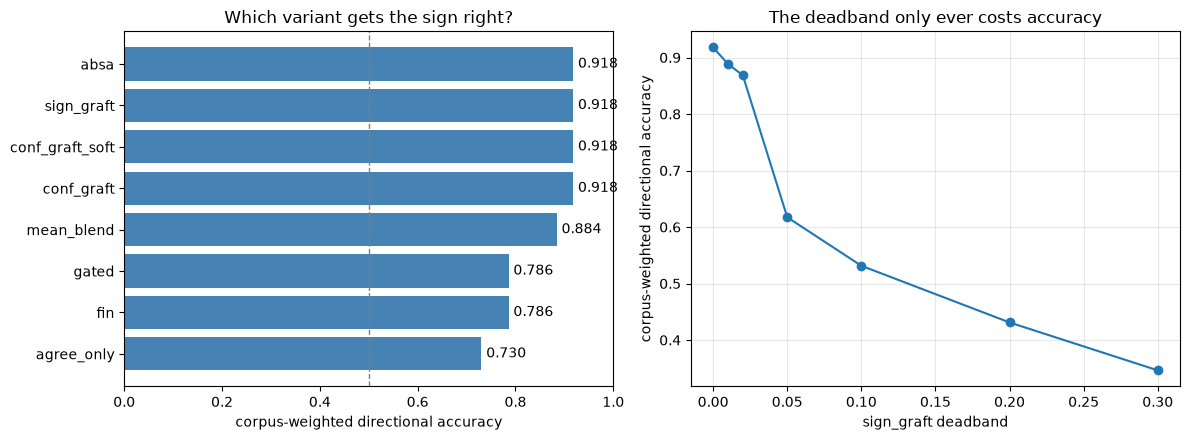

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = results.sort_values("corpus_dir_acc")
axes[0].barh(order.index, order["corpus_dir_acc"], color="steelblue")
axes[0].axvline(0.5, ls="--", lw=1, color="grey")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("corpus-weighted directional accuracy")
axes[0].set_title("Which variant gets the sign right?")
for i, (name, row) in enumerate(order.iterrows()):
    axes[0].text(row["corpus_dir_acc"] + 0.01, i, f"{row['corpus_dir_acc']:.3f}", va="center")

sw = pd.DataFrame(sweep)
axes[1].plot(sw["deadband"], sw["corpus_dir_acc"], marker="o")
axes[1].set_xlabel("sign_graft deadband")
axes[1].set_ylabel("corpus-weighted directional accuracy")
axes[1].set_title("The deadband only ever costs accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS_DIR / "figures" / "2.4-fusion-accuracy.png", dpi=120)
plt.show()

## 10. Are the labels any good?

Everything above is measured against 300 judgements made by one annotator -- who also designed the
variants being judged. Blind labelling hid the scores, so no individual label could be nudged toward
a variant, but it does not remove the deeper problem: the hypothesis was written before the labelling,
so any bias would be *systematic*.

Worse, with a single annotator there is no way to know how **subjective** the task is. If two careful
annotators would only agree 80% of the time, a variant scoring 0.918 is at the ceiling and the fine
distinctions between the leaders are noise.

So the same 300 sentences were labelled twice more, by two annotators working from
`references/fusion-labelling-protocol.md` alone -- blind to every model score, to the existing labels,
and to the fact that scoring variants were being evaluated at all.

**These are LLM annotators, and that limits what the result can mean.** They are not independent human
validation, and nothing here establishes that any label set is more *accurate* than another; there is
no external ground truth. What three label sets do buy is three things the single set could not: an
estimate of how tightly the protocol constrains the task, an estimate of the **ceiling**, and the
ability to recompute every headline against labels the first annotator did not produce.

In [21]:
raters = {"me": "fusion-labels.csv", "llm_a": "fusion-labels-llm-a.csv",
          "llm_b": "fusion-labels-llm-b.csv"}
lab = df[["sample_id", "stratum"] + list(VARIANTS)].copy()
for name, fn in raters.items():
    lab = lab.merge(pd.read_csv(PROJ_ROOT / "references" / fn)
                    .rename(columns={"label": f"lab_{name}"}), on="sample_id", how="left")

print("label distributions:")
print(pd.DataFrame({n: lab[f"lab_{n}"].value_counts().sort_index() for n in raters}).to_string())

label distributions:
       me  llm_a  llm_b
-1.0   53     23     17
-0.5   55     84     88
 0.0  110    100    104
 0.5   46     78     75
 1.0   36     15     16


In [22]:
def quadratic_kappa(a, b):
    """Cohen's kappa with quadratic weights -- the right statistic for an ordinal
    scale, since it penalises a +1.0/-1.0 clash far more than +1.0/+0.5."""
    cats = sorted(set(a) | set(b)); idx = {c: i for i, c in enumerate(cats)}; k = len(cats)
    O = np.zeros((k, k))
    for x, y in zip(a, b):
        O[idx[x], idx[y]] += 1
    O /= O.sum()
    ha = np.array([np.mean([idx[x] == i for x in a]) for i in range(k)])
    hb = np.array([np.mean([idx[y] == i for y in b]) for i in range(k)])
    Wt = np.array([[((i - j) / (k - 1)) ** 2 for j in range(k)] for i in range(k)])
    return 1 - (Wt * O).sum() / (Wt * np.outer(ha, hb)).sum()

import itertools
rows = []
for x, y in itertools.combinations(raters, 2):
    a, b = lab[f"lab_{x}"], lab[f"lab_{y}"]
    d, sd = a != b, np.sign(a) != np.sign(b)
    rows.append({"pair": f"{x} vs {y}", "exact": (a == b).mean(),
                 "sign": (np.sign(a) == np.sign(b)).mean(),
                 "quad_kappa": quadratic_kappa(list(a), list(b)),
                 "disagree_on_sign": int(sd.sum()),
                 "disagree_on_intensity_only": int((d & ~sd).sum())})
pd.DataFrame(rows).set_index("pair").round(3)

,exact,sign,quad_kappa,disagree_on_sign,disagree_on_intensity_only
pair,,,,,
me vs llm_a,0.637,0.817,0.800,55,54
me vs llm_b,0.660,0.853,0.856,44,58
llm_a vs llm_b,0.833,0.860,0.870,42,8


In [23]:
all_agree = ((np.sign(lab["lab_me"]) == np.sign(lab["lab_llm_a"]))
             & (np.sign(lab["lab_llm_a"]) == np.sign(lab["lab_llm_b"])))
print(f"all three annotators agree on SIGN: {int(all_agree.sum())} of {len(lab)} "
      f"({100*all_agree.mean():.1f}%)")
print()
print("This is the CEILING. No scorer can be judged correct on sentences the")
print("annotators themselves cannot agree about.")

all three annotators agree on SIGN: 232 of 300 (77.3%)

This is the CEILING. No scorer can be judged correct on sentences the
annotators themselves cannot agree about.


Three things fall out, and one of them is a direct rebuttal of a caveat stated earlier in this
section.

**The protocol is tightly specified.** Quadratic-weighted kappa runs 0.80-0.87 across all three pairs
-- "substantial to almost perfect" by the usual reading. The labels follow from the written rules
rather than from one annotator's private expectations.

**But the two LLM annotators are visibly NOT independent of each other.** They agree with each other
on 83.3% of labels exactly, while agreeing with the first annotator on only 63.7% and 66.0%. Same
model family, same clustering. This is exactly why the word "independent" cannot be used for them:
they are independent of the first annotator's *labels*, not of its *reasoning*. A second human would
not cluster like this.

**The disagreements are mostly about intensity, not direction.** Against the first annotator, roughly
half of all disagreements are intensity-only -- the LLM annotators use the half-points far more and
the extremes far less (they place 5-8% of sentences at ±1.0; the first annotator places 30%). The
five-point scale is being applied on a different internal calibration, while direction largely
survives.

**The ceiling is 77.3%.** All three annotators agree on the sign of only 232 of the 300 sentences.
That number governs how much of this notebook's ranking can be believed, and section 10.2 spends it.

### 10.1 The headline, recomputed against labels the author did not write

In [24]:
POP_W = {"absa_flat": 4233, "agree_strong": 3186, "disagree_plain": 2756,
         "agree_weak": 1861, "resolved": 1277, "disagree_comparative": 634}
_t = sum(POP_W.values()); POP_W = {k: v / _t for k, v in POP_W.items()}

def acc_against(col, labcol):
    d = lab[lab[labcol] != 0]
    return sum(POP_W[st] * (np.sign(g[col]) == np.sign(g[labcol])).mean()
               for st, g in d.groupby("stratum"))

acc = pd.DataFrame({n: {v: acc_against(v, f"lab_{n}") for v in VARIANTS} for n in raters})
acc["spread_across_raters"] = acc.max(axis=1) - acc.min(axis=1)
acc.sort_values("me", ascending=False).round(3)

,me,llm_a,llm_b,spread_across_raters
absa,0.918,0.905,0.928,0.023
sign_graft,0.918,0.905,0.928,0.023
conf_graft_soft,0.918,0.905,0.928,0.023
conf_graft,0.918,0.905,0.928,0.023
mean_blend,0.884,0.888,0.892,0.008
fin,0.786,0.804,0.795,0.018
gated,0.786,0.804,0.795,0.018
agree_only,0.730,0.733,0.740,0.010


**The ranking is identical under all three label sets**, and every variant moves by at most 0.023
depending on who labelled. The four ABSA-sign variants tie at 0.905-0.928 (they tie by construction --
none of them alters the sign), `mean_blend` sits at 0.884-0.892, and the two FinBERT-sign variants at
0.786-0.804.

**The ~12-point gap between ABSA-sign and FinBERT-sign variants survives intact under every
annotator.** That is the central claim of this notebook, and it does not depend on who did the
labelling.

### 10.2 What the ceiling does and does not permit

With annotators agreeing on sign for 77.3% of sentences, claims of the form "variant X beats variant Y
by 3 points" are not supportable -- that difference is smaller than the disagreement between the
people doing the measuring. Concretely, the separation between `conf_graft` (Spearman 0.760) and
`absa` (0.730) in section 8 remains **undefended**, exactly as section 12 warns.

What survives comfortably is the 12-point direction gap, which is roughly four times the
between-annotator variation and holds under all three label sets independently.

In [25]:
print("magnitude finding recomputed -- rho(|score|, |label|) on rows where")
print("fin AND absa both have the correct sign, so only the magnitude differs\n")
out = []
for n in raters:
    lc = f"lab_{n}"
    d = lab[lab[lc] != 0]
    common = d[(np.sign(d["fin"]) == np.sign(d[lc])) & (np.sign(d["absa"]) == np.sign(d[lc]))]
    out.append({"rater": n, "n": len(common),
                "finbert_magnitude": spearmanr(common["fin"].abs(), common[lc].abs()).statistic,
                "absa_magnitude": spearmanr(common["absa"].abs(), common[lc].abs()).statistic})
mag_check = pd.DataFrame(out).set_index("rater")
mag_check["gap"] = mag_check["finbert_magnitude"] - mag_check["absa_magnitude"]
mag_check.round(3)

magnitude finding recomputed -- rho(|score|, |label|) on rows where
fin AND absa both have the correct sign, so only the magnitude differs



,n,finbert_magnitude,absa_magnitude,gap
rater,,,,
me,119,0.461,0.298,0.163
llm_a,126,0.412,0.135,0.278
llm_b,130,0.490,0.171,0.319


This is the result that rebuts our own caveat. The worry with LLM annotators was that one asked "what
is the sentiment toward Tesla" is doing essentially **ABSA's task with a bigger model**, so ABSA might
be flattered by shared inductive bias.

The opposite happened. Against the two LLM annotators, ABSA's magnitude correlation *falls* to 0.135
and 0.171 -- far below the 0.298 it scored against the first annotator -- while FinBERT holds at
0.412-0.490. The measured gap **widens** from 0.163 to 0.278 and 0.319.

So the second half of the hypothesis -- that magnitude belongs to FinBERT -- comes out of this check
stronger than it went in, and the flattery concern is not merely unproven but pointed the wrong way.

In plain terms: we asked two more annotators to grade the same 300 sentences without telling them what
was being tested, and the big conclusions came back unchanged while the small ones stayed unprovable.
The labels are reproducible from a written protocol rather than idiosyncratic to one reader, which is
a real strengthening -- but they are still not human validation, and this section is not evidence that
any of these scorers is *accurate* in any absolute sense.

## 11. Verdict

The hypothesis was that attribution and intensity are separable and come from different models. **Both
halves are confirmed**, on independent evidence:

- **direction belongs to ABSA** -- 0.918 against FinBERT's 0.786 corpus-weighted, and 90% against 10%
  on the comparative disagreements;
- **magnitude belongs to FinBERT** -- rho 0.461 against 0.298 on the common subset, AUC 0.769 against
  0.674 separating strong from mild, 0.513 against 0.193 on the finer by-eye ranking, and extremes
  that pick out earnings and deliveries rather than "the ladies in my house love it".

Neither model is good at both. Pulling all eight together:

| variant | direction | Spearman | magnitude (rho) | extreme prec. | shout-right | noise on neutrals | dyn. range |
|---|---|---|---|---|---|---|---|
| `conf_graft` | **0.918** | **0.760** | 0.465 | 0.90 | **2.55** | **0.052** | 0.672 |
| `conf_graft_soft` | **0.918** | 0.739 | 0.485 | 0.90 | 1.61 | 0.154 | 0.993 |
| `absa` | **0.918** | 0.730 | 0.298 | 0.75 | 1.87 | 0.176 | 0.979 |
| `sign_graft` | **0.918** | 0.724 | 0.461 | 0.85 | 1.39 | 0.256 | **1.315** |
| `agree_only` | 0.730 | 0.717 | 0.461 | **0.95** | artefact | 0.193 | 1.240 |
| `mean_blend` | 0.884 | 0.708 | **0.504** | **0.95** | 1.99 | 0.199 | 1.072 |
| `fin` | 0.786 | 0.528 | 0.461 | 0.90 | 2.02 | 0.256 | 1.165 |
| `gated` | 0.786 | 0.459 | 0.443 | 0.85 | 2.26 | 0.068 | 0.595 |

Four variants tie at the top on direction, because all four take ABSA's sign and none of them can
alter it. So direction no longer separates the leaders, and the choice is decided entirely on how
each one behaves on magnitude and on its mistakes.

**`conf_graft` is the best-behaved variant we have, and it is the one to adopt.** It wins or ties on
almost every axis at once:

- **best overall Spearman of all eight (0.760)**, ahead of ABSA's 0.730 and `sign_graft`'s 0.724;
- ties the top on direction (0.918), since scaling by a non-negative confidence cannot change a sign;
- improves on `sign_graft`'s magnitude rho and lifts extreme precision from 0.85 to 0.90;
- **best shout-when-right ratio of all eight (2.55)**, beating even FinBERT's 2.02;
- **best error amplification of anything tested including both parents** -- 0.393 against ABSA's 0.535
  and `sign_graft`'s 0.720, so it is quiet exactly when it is wrong;
- **quietest of all eight on neutral sentences (0.052)**, better even than `gated`, which is
  significant because neutral sentences are 37% of the sample and every one of them is noise fed into
  an article mean.

Its one weakness is a narrow dynamic range (0.672), the second-narrowest overall. That matters if a
downstream model needs the score to express *how big* a deal something is rather than merely to rank
sentences against each other.

**`conf_graft_soft` is the one to carry beside it**, as the same idea with the range restored: 0.993
of spread and the best magnitude rho of any variant (0.485), giving up some of the quietness.

**`mean_blend` remains the honourable mention.** Included as a strawman to embarrass the clever
variants, it still finishes best on magnitude (0.504) and tied-best on extreme precision (0.95), for
3.4 points of direction -- roughly six sentences, inside the noise.

Recommendation: **adopt `conf_graft` as the primary entity-scoped score, carry `conf_graft_soft` and
`mean_blend` alongside**, and let the first downstream metric choose between three good candidates
rather than eight speculative ones. FinBERT and ABSA both stay, since both feed all three.

Two of our own design decisions did **not** survive:

- **`gated`, argued in 2.3 to be the most principled variant, is structurally incapable of helping.**
  It cannot flip a sign, and the errors are sign errors. It is dominated on every measure here except
  quietness on neutral sentences.
- **The deadband, added to make `sign_graft` safer, was its single biggest weakness** -- 39 points of
  accuracy surrendered to guard against a failure mode that does not occur. And the instinct behind
  it was not wrong, only the instrument was: uncertain ABSA calls really should be quieter, which is
  exactly what `conf_graft` achieves by multiplying rather than thresholding.

In plain terms: FinBERT knows how much a sentence matters, ABSA knows who it is about, and taking one
from each really does beat either alone. The refinement that mattered was letting ABSA say *how sure*
it is instead of just which way to point -- that single change produced the quietest, best-behaved
score in the set. Worth noting against all of it: the naive average is still, annoyingly, hard to
beat.

## 12. Limitations

- **The first annotator designed the variants.** Section 10 addresses this as far as it can: two
  further annotators labelled the same 300 sentences from the protocol alone, the ranking came out
  identical, and the direction gap held under all three. But both are LLM annotators and they cluster
  with each other (83.3% exact agreement) far more than with the first (63.7%, 66.0%), so this is
  reproducibility, not independent human validation. A human second annotator remains the missing
  piece.
- **300 sentences, six strata, reweighted.** The corpus-weighted numbers inherit the noise of 50-row
  per-stratum estimates. `disagree_comparative` carries only 4.5% of the corpus weight, so its
  dramatic 0.103-versus-0.897 split moves the headline less than it appears to.
- **This measures agreement with a human reading of financial sentiment, not returns.** It is
  entirely possible for the better-attributed score to be the worse predictor. Nothing here tests
  that, and nothing in this project does yet.
- **Neutral sentences are 37% of the sample** and are excluded from directional accuracy by
  construction. `mean_abs_on_neutral` is the only column that speaks to them; `gated` wins it
  decisively (0.068 against FinBERT's 0.256), which is a genuine virtue this notebook otherwise gives
  it no credit for.
- **The variants were specified before the sample was labelled, but the deadband sweep was run
  after.** The τ=0 result is therefore a post-hoc fix rather than a pre-registered prediction. It is
  a large, monotonic and mechanistically explained effect, but it was found by looking.
- **The fine-grained ranking is 30 sentences.** It agrees with the 119-row common-subset analysis on
  direction of effect and on the size of ABSA's magnitude deficit, which is why it is reported, but
  on its own it would be far too small to conclude anything.
- **`sign_graft` and `mean_blend` are separated by a few sentences, not a clear margin.** 3.4 points
  of directional accuracy on 190 rows is roughly six sentences. The gap between those two is inside
  the noise; the gap between either of them and `fin`/`gated` is not.

## 13. Where this leaves the pipeline

Concretely, from this notebook:

1. `fusion.py` now defaults `DEADBAND` to 0.0, on the evidence in section 5. The deadband applies to
   `sign_graft` only -- the `conf_graft` variants replace thresholding with weighting, which is the
   better answer to the same problem.
2. `conf_graft` becomes the primary entity-scoped score, with `conf_graft_soft` and `mean_blend`
   carried alongside. FinBERT and ABSA both remain, since both feed all three.
3. `gated` stays in the module but is not a candidate. Its only remaining virtue is how quiet it is
   on neutral sentences (mean |score| 0.068 against FinBERT's 0.256).
4. The article-level aggregation in `sentiment.py` is untouched by this notebook. Turning a chosen
   per-sentence variant into an article feature is the obvious next piece of text work.

And the thing this still cannot settle: every number here is agreement with a careful reader. Whether
a better-attributed sentiment score is a better *predictor* needs forward returns, which live in the
market layer and are somebody else's work. Until that exists, the strongest claim available is the
one this notebook makes -- that ABSA reads these sentences the way a person does considerably more
often than FinBERT, and that if we are going to average sentence scores into a feature, it matters a
great deal that the errors we average are quiet ones.